# Bank EDA — Python/Pandas: Charts & Statistical Tests
### Two things only: visualisations + statistical validation
Fill in every `___` blank. Answer key at the bottom.

In [1]:
# Run this as-is — no changes needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr

df = pd.read_csv('bank.csv')
df['deposit_bin'] = (df['deposit'] == 'yes').astype(int)  # yes=1, no=0

plt.style.use('seaborn-v0_8-darkgrid')
print('Ready. Rows:', len(df))

Ready. Rows: 11162


---
## PART 1 — matplotlib / seaborn charts
---

### Chart 1 — Histogram: Age distribution

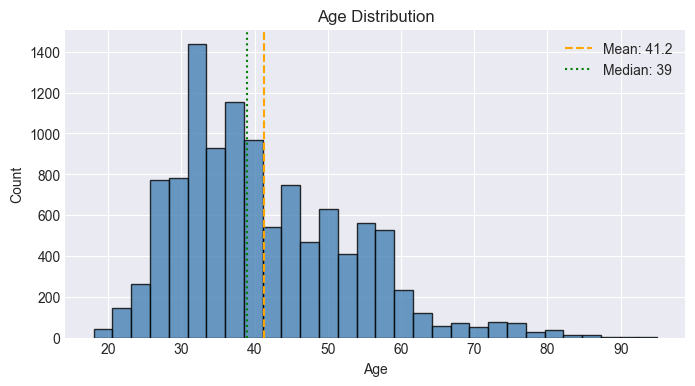

In [3]:
# What: shows how age is spread across all customers
# Why: check for skew, spot dominant age groups

plt.figure(figsize=(8, 4))

plt.hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
#             ^column name    ^try 30

plt.axvline(df['age'].mean(),   color='orange', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
plt.axvline(df['age'].median(), color='green',  linestyle=':',  label=f"Median: {df['age'].median():.0f}")

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

# What do you notice about the shape?

### Chart 2 — Bar chart: Conversion rate by job

job
student          74.7
retired          66.3
unemployed       56.6
management       50.7
unknown          48.6
admin.           47.3
self-employed    46.2
technician       46.1
services         40.0
housemaid        39.8
entrepreneur     37.5
blue-collar      36.4
Name: deposit_bin, dtype: float64


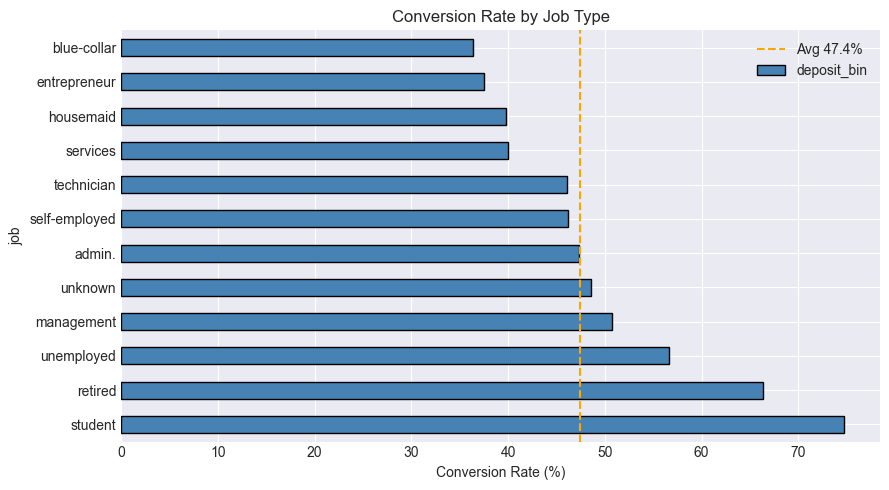

In [8]:
# What: which job type subscribes the most?
# Pattern you'll use forever: groupby → mean → mul(100)

job_conv = (
    df.groupby('job')['deposit_bin']   # groupby 'job', take 'deposit_bin'
    .mean()                # mean gives you the conversion rate as 0.xx
    .mul(100)              # multiply by 100 to get percentage
    .round(1)
    .sort_values(ascending=False)
)
print(job_conv)
plt.figure(figsize=(9, 5))
job_conv.plot(kind='barh', color='steelblue', edgecolor='black')
plt.axvline(47.4, color='orange', linestyle='--', label='Avg 47.4%')
plt.title('Conversion Rate by Job Type')
plt.xlabel('Conversion Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

### Chart 3 — Boxplot: Call duration by deposit outcome

/var/folders/_s/2n6ftdqj41s073swk7878ddc0000gn/T/ipykernel_54977/2361986822.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


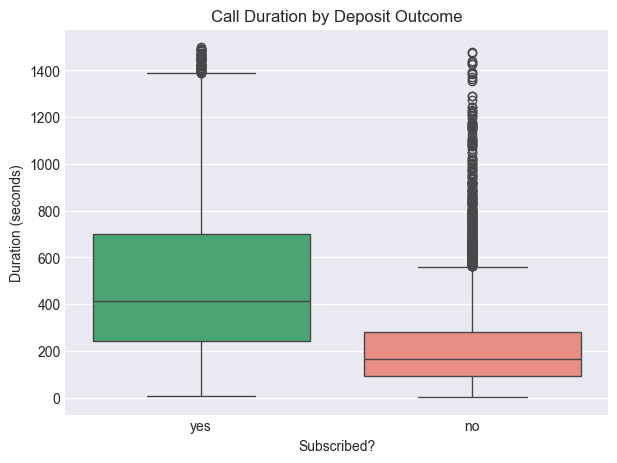

deposit
no     223.0
yes    537.0
Name: duration, dtype: float64


In [9]:
# What: shows the full spread of duration for yes vs no customers
# Why boxplot and not bar: bar only shows mean — boxplot shows median, spread, and outliers

plt.figure(figsize=(7, 5))

sns.boxplot(
    x='deposit',          # 'deposit' — the group
    y='duration',          # 'duration' — the value
    data=df[df['duration'] < 1500],   # clipping extreme outliers for visibility
    palette={'yes': 'mediumseagreen', 'no': 'salmon'}
)

plt.title('Call Duration by Deposit Outcome')
plt.xlabel('Subscribed?')
plt.ylabel('Duration (seconds)')
plt.show()

# Print mean for each group
print(df.groupby('deposit')['duration'].mean().round(0))
# Expected: yes ~537s vs no ~223s — big difference

### Chart 4 — Line chart: Campaign fatigue

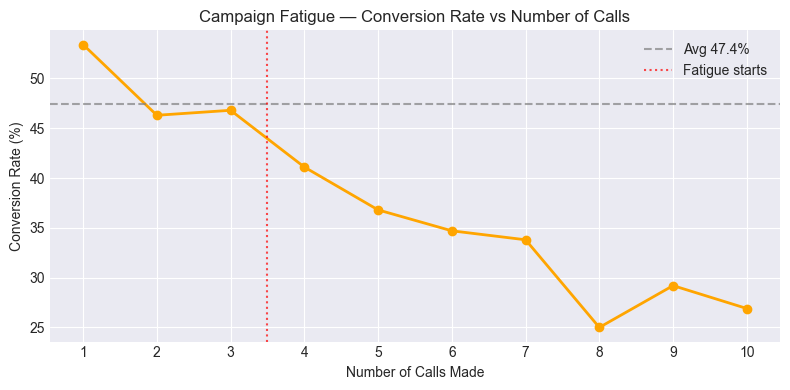

campaign
1     53.4
2     46.3
3     46.8
4     41.1
5     36.8
6     34.7
7     33.8
8     25.0
9     29.2
10    26.9
Name: deposit_bin, dtype: float64


In [10]:
# What: does conversion drop as more calls are made?

camp_conv = (
    df[df['campaign'] <= 10]
    .groupby('campaign')['deposit_bin']     # groupby 'campaign', take 'deposit_bin'
    .mean().mul(100).round(1)
)

plt.figure(figsize=(8, 4))
plt.plot(camp_conv.index, camp_conv.values, marker='o', color='orange', linewidth=2)
plt.axhline(47.4, color='gray', linestyle='--', alpha=0.7, label='Avg 47.4%')
plt.axvline(3.5,  color='red',  linestyle=':',  alpha=0.7, label='Fatigue starts')
plt.title('Campaign Fatigue — Conversion Rate vs Number of Calls')
plt.xlabel('Number of Calls Made')
plt.ylabel('Conversion Rate (%)')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

print(camp_conv)

### Chart 5 — Heatmap: Correlation matrix

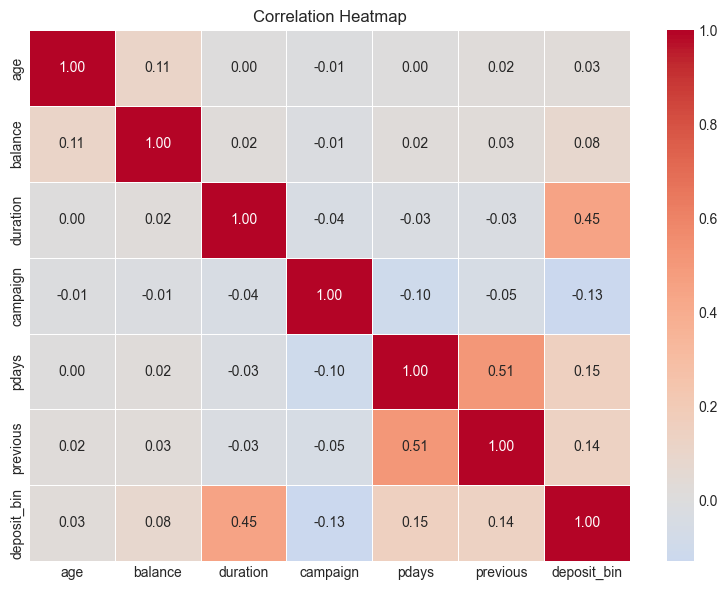


Correlation with deposit:
deposit_bin    1.000
duration       0.452
pdays          0.152
previous       0.140
balance        0.081
age            0.035
campaign      -0.128
Name: deposit_bin, dtype: float64


In [11]:
# What: shows how all numeric columns relate to each other and to deposit
# Key: duration has the highest correlation with deposit_bin (r=0.45)

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'deposit_bin']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,           # the correlation matrix
    annot=True,    # show numbers inside each cell
    fmt='.2f',     # '.2f' = 2 decimal places
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print just the deposit_bin row — which feature correlates most?
print('\nCorrelation with deposit:')
print(corr['deposit_bin'].sort_values(ascending=False).round(3))

---
## PART 2 — Statistical Validation

The SQL findings told us *what*. Statistics tells us *whether to trust it*.

| Situation | Test to use | What p-value means |
|---|---|---|
| Categorical column vs deposit | Chi-Square | Are they related or random? |
| Numeric column vs deposit | T-Test | Are the group means really different? |
| Numeric column vs deposit (strength) | Point-Biserial | How strongly correlated? |

**Rule:** p < 0.05 = significant (you can trust the finding). p ≥ 0.05 = could be random noise.

---

### Test 1 — Chi-Square: Categorical columns vs deposit

In [12]:
# How it works:
# Step 1 — build a crosstab: counts of deposit=yes/no for each category value
# Step 2 — chi2_contingency() tests: is this distribution random, or is there a real pattern?
# Step 3 — read the p-value

# Example first — run this to understand the output:
example_crosstab = pd.crosstab(df['job'], df['deposit'])
print('Crosstab example (job vs deposit):')
print(example_crosstab.head())

chi2, p, dof, expected = chi2_contingency(example_crosstab)
print(f'\nchi2={chi2:.2f}, p={p:.6f}')
print('p < 0.05?', p < 0.05, '→ job IS significantly related to deposit')

Crosstab example (job vs deposit):
deposit         no   yes
job                     
admin.         703   631
blue-collar   1236   708
entrepreneur   205   123
housemaid      165   109
management    1265  1301

chi2=378.08, p=0.000000
p < 0.05? True → job IS significantly related to deposit


In [13]:
# Now YOUR TURN — run chi-square for ALL categorical columns

cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

print(f'{"Column":<15} {"Chi2":>10} {"p-value":>12} {"Significant?"}')
print('-' * 55)

for col in cat_cols:
    ct = pd.crosstab(df[col], df['deposit'])    # col vs deposit
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '✓ YES' if p < 0.05 else '✗ NO'  # fill in the threshold
    print(f'{col:<15} {chi2:>10.2f} {p:>12.6f}  {sig}')

# Expected: all 9 columns should show ✓ YES

Column                Chi2      p-value Significant?
-------------------------------------------------------
job                 378.08     0.000000  ✓ YES
marital             109.58     0.000000  ✓ YES
education           122.77     0.000000  ✓ YES
default              17.81     0.000024  ✓ YES
housing             463.19     0.000000  ✓ YES
loan                135.83     0.000000  ✓ YES
contact             736.69     0.000000  ✓ YES
month              1046.77     0.000000  ✓ YES
poutcome           1004.64     0.000000  ✓ YES


### Test 2 — T-Test: Numeric columns vs deposit

In [14]:
# How it works:
# Split customers into yes group and no group
# ttest_ind() asks: is the mean of column X genuinely different between yes and no?
# If p < 0.05 → yes, the difference is real, not random

# YOUR TURN — create the two groups:
yes_group = df[df['deposit'] == 'yes']   # 'yes'
no_group  = df[df['deposit'] == 'no']   # 'no'

print(f'Yes group: {len(yes_group)} customers')
print(f'No group:  {len(no_group)} customers')

Yes group: 5289 customers
No group:  5873 customers


In [15]:
# Now run t-test for each numeric column

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

print(f'{"Column":<12} {"Yes Mean":>10} {"No Mean":>10} {"t-stat":>8} {"p-value":>12} {"Sig?"}')
print('-' * 70)

for col in num_cols:
    t, p = ttest_ind(yes_group[col], no_group[col], equal_var=False)
    #                          ^col                    ^col
    yes_mean = yes_group[col].mean()  # .mean()
    no_mean  = no_group[col].mean()    # .mean()
    sig = '✓ YES' if p < 0.05 else '✗ NO'
    print(f'{col:<12} {yes_mean:>10.1f} {no_mean:>10.1f} {t:>8.2f} {p:>12.6f}  {sig}')

# What to look for:
# duration: yes_mean=537 vs no_mean=223 — massive difference, t=51.97
# campaign: yes_mean=2.1 vs no_mean=2.8 — subscribed customers needed fewer calls

Column         Yes Mean    No Mean   t-stat      p-value Sig?
----------------------------------------------------------------------
age                41.7       40.8     3.64     0.000276  ✓ YES
balance          1804.3     1280.2     8.52     0.000000  ✓ YES
duration          537.3      223.1    51.97     0.000000  ✓ YES
campaign            2.1        2.8   -13.99     0.000000  ✓ YES
pdays              68.7       35.7    16.03     0.000000  ✓ YES
previous            1.2        0.5    14.73     0.000000  ✓ YES


### Test 3 — Point-Biserial Correlation: How strongly does each numeric feature predict deposit?

In [16]:
# Point-biserial = correlation between a numeric column and a binary (0/1) column
# r close to 1 or -1 = strong predictor
# r close to 0 = weak predictor

print(f'{"Column":<12} {"r":>8} {"p-value":>12} {"Strength"}')
print('-' * 50)

for col in ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']:
    r, p = pointbiserialr(df['deposit_bin'], df[col])   # deposit_bin, then the numeric col
    strength = 'STRONG' if abs(r) > 0.3 else ('MODERATE' if abs(r) > 0.1 else 'WEAK')
    direction = '↑ more = more likely yes' if r > 0 else '↓ more = less likely yes'
    print(f'{col:<12} {r:>8.3f} {p:>12.6f}  {strength} — {direction}')

# Expected:
# duration  r=0.452  STRONG
# campaign  r=-0.128 MODERATE (negative — more calls = less likely)
# pdays     r=0.152  MODERATE
# balance   r=0.081  WEAK
# age       r=0.035  WEAK

Column              r      p-value Strength
--------------------------------------------------
age             0.035     0.000226  WEAK — ↑ more = more likely yes
balance         0.081     0.000000  WEAK — ↑ more = more likely yes
duration        0.452     0.000000  STRONG — ↑ more = more likely yes
campaign       -0.128     0.000000  MODERATE — ↓ more = less likely yes
pdays           0.152     0.000000  MODERATE — ↑ more = more likely yes
previous        0.140     0.000000  MODERATE — ↑ more = more likely yes


### Summary — All findings now statistically validated

In [17]:
# This table connects your SQL findings to statistical proof
# Run as-is

summary = [
    ['duration',  'T-test',      't=51.97', 'p<0.0001', 'STRONG',   '537s(yes) vs 223s(no)'],
    ['month',     'Chi-square',  'χ²=1047', 'p<0.0001', 'STRONG',   'Dec/Mar/Sep/Oct best'],
    ['poutcome',  'Chi-square',  'χ²=1005', 'p<0.0001', 'STRONG',   'Previous success = best'],
    ['contact',   'Chi-square',  'χ²=737',  'p<0.0001', 'HIGH',     'Cellular better than phone'],
    ['housing',   'Chi-square',  'χ²=463',  'p<0.0001', 'HIGH',     'No housing loan converts more'],
    ['campaign',  'T-test',      't=-13.99','p<0.0001', 'MODERATE', 'Fatigue confirmed at 4+ calls'],
    ['pdays',     'T-test',      't=16.03', 'p<0.0001', 'MODERATE', '31-90 day window confirmed'],
    ['balance',   'T-test',      't=8.52',  'p<0.0001', 'WEAK',     'Higher balance = slightly more'],
    ['age',       'T-test',      't=3.64',  'p=0.0003', 'WEAK',     'U-shape: young+old best'],
]

print(f'{"Feature":<12} {"Test":<14} {"Statistic":<10} {"p-value":<12} {"Strength":<10} {"Finding"}')
print('─' * 90)
for row in summary:
    print(f'{row[0]:<12} {row[1]:<14} {row[2]:<10} {row[3]:<12} {row[4]:<10} {row[5]}')

print('\n✓ Every SQL finding is now statistically confirmed.')
print('✓ All p-values < 0.05 — none of these are random noise.')

Feature      Test           Statistic  p-value      Strength   Finding
──────────────────────────────────────────────────────────────────────────────────────────
duration     T-test         t=51.97    p<0.0001     STRONG     537s(yes) vs 223s(no)
month        Chi-square     χ²=1047    p<0.0001     STRONG     Dec/Mar/Sep/Oct best
poutcome     Chi-square     χ²=1005    p<0.0001     STRONG     Previous success = best
contact      Chi-square     χ²=737     p<0.0001     HIGH       Cellular better than phone
housing      Chi-square     χ²=463     p<0.0001     HIGH       No housing loan converts more
campaign     T-test         t=-13.99   p<0.0001     MODERATE   Fatigue confirmed at 4+ calls
pdays        T-test         t=16.03    p<0.0001     MODERATE   31-90 day window confirmed
balance      T-test         t=8.52     p<0.0001     WEAK       Higher balance = slightly more
age          T-test         t=3.64     p=0.0003     WEAK       U-shape: young+old best

✓ Every SQL finding is now statist

---
## Answer Key
Only look after you've tried!

In [ ]:
print("""
CHART 1:  plt.hist(df['age'], bins=30, ...)

CHART 2:  df.groupby('job')['deposit_bin'].mean().mul(100)

CHART 3:  sns.boxplot(x='deposit', y='duration', data=...)

CHART 4:  df.groupby('campaign')['deposit_bin'].mean()...

CHART 5:  sns.heatmap(corr, annot=True, fmt='.2f', ...)

TEST 1:   ct = pd.crosstab(df[col], df['deposit'])
          chi2, p, dof, _ = chi2_contingency(ct)
          sig = '✓ YES' if p < 0.05 else '✗ NO'

TEST 2:   yes_group = df[df['deposit'] == 'yes']
          no_group  = df[df['deposit'] == 'no']
          t, p = ttest_ind(yes_group[col], no_group[col], equal_var=False)
          yes_mean = yes_group[col].mean()

TEST 3:   r, p = pointbiserialr(df['deposit_bin'], df[col])
""")